In [37]:
import torch

# Introduction to PyTorch, a Deep Learning Library

Self-driving cars, smartphones, search engines... Deep learning is now everywhere. Before you begin building complex models, you will become familiar with PyTorch, a deep learning framework. You will learn how to manipulate tensors, create PyTorch data structures, and build your first neural network in PyTorch with linear layers.

## Getting started with PyTorch tensors
Tensors are PyTorch's core data structure and the foundation of deep learning. They're similar to NumPy arrays but have unique features.

Here you have a Python list named temperatures containing daily readings from two weather stations. Try converting this into a tensor!

Instructions
100 XP
Begin by importing torch.
Create a tensor from the Python list temperatures.

In [38]:
temperatures = [[72, 75, 78], [70, 73, 76]]

# Create a tensor from temperatures
temp_tensor = torch.tensor(temperatures)

print(temp_tensor)

tensor([[72, 75, 78],
        [70, 73, 76]])


## Checking and adding tensors
While collecting temperature data, you notice the readings are off by two degrees. Add two degrees to the temperatures tensor after verifying its shape and data type with torch to ensure compatibility with the adjustment tensor.

The torch library and the temperatures tensor are loaded for you.

Instructions 1/2
50 XP
Display the shape of the adjustment tensor.
Display the data type of the adjustment tensor.

In [39]:
adjustment = torch.tensor([[2, 2, 2], [2, 2, 2]])

# Display the adjustment tensor
print("Adjustment tensor:", adjustment)

# Display the shape of the adjustment tensor
print("Adjustment shape:", adjustment.shape)

# Display the type of the adjustment tensor
print("Adjustment type:", adjustment.dtype)

print("\n")
print("Temperatures tensor:", temp_tensor)
print("Temperatures shape:", temp_tensor.shape)
print("Temperatures type:", temp_tensor.dtype)

Adjustment tensor: tensor([[2, 2, 2],
        [2, 2, 2]])
Adjustment shape: torch.Size([2, 3])
Adjustment type: torch.int64


Temperatures tensor: tensor([[72, 75, 78],
        [70, 73, 76]])
Temperatures shape: torch.Size([2, 3])
Temperatures type: torch.int64


Add the temperatures and adjustment tensors.

In [40]:
# Add the temperatures and adjustment tensors
corrected_temperatures = temp_tensor + adjustment
print("Corrected temperatures:", corrected_temperatures)

Corrected temperatures: tensor([[74, 77, 80],
        [72, 75, 78]])


## Linear layer network
Neural networks often contain many layers, but most of them are linear layers. Understanding a single linear layer helps you grasp how they work before adding complexity.

Apply a linear layer to an input tensor and observe the output.

Instructions
100 XP
Create a Linear layer that takes 3 features as input and returns 2 outputs.
Pass input_tensor through the linear laye

In [41]:
import torch.nn as nn

input_tensor = torch.tensor([[0.3471, 0.4547, -0.2356]])

# Create a Linear layer
linear_layer = nn.Linear(
                         in_features=3, 
                         out_features=2
                         )

# Pass input_tensor through the linear layer
output = linear_layer(input_tensor)

print(output)

tensor([[ 0.6848, -0.1045]], grad_fn=<AddmmBackward0>)


## Your first neural network
It's time for you to implement a small neural network containing two linear layers in sequence.

Instructions
100 XP
Add a container for stacking layers in sequence.

In [42]:
input_tensor = torch.Tensor([[2, 3, 6, 7, 9, 3, 2, 1]])

# Create a container for stacking linear layers
model = nn.Sequential(nn.Linear(8, 4),
                nn.Linear(4, 1)
                )

output = model(input_tensor)
print(output)

tensor([[2.1693]], grad_fn=<AddmmBackward0>)


## Counting the number of parameters
Deep learning models are famous for having a lot of parameters. With more parameters comes more computational complexity and longer training times, and a deep learning practitioner must know how many parameters their model has.

In this exercise, you'll first calculate the number of parameters manually. Then, you'll verify your result using the .numel() method.

Instructions 1/2
50 XP
Question
Manually calculate the number of parameters of the model below. How many does it have? Use the console as a calculator.

model = nn.Sequential(nn.Linear(9, 4),
                      nn.Linear(4, 2),
                      nn.Linear(2, 1))

answer = 53

In [43]:
(9 + 1)*4 + (4 + 1)*2 + (2 + 1)*1

53

Use .numel() to confirm your manual calculation by iterating through the model's parameters to updating the total variable.

In [44]:
model = nn.Sequential(nn.Linear(9, 4),
                      nn.Linear(4, 2),
                      nn.Linear(2, 1))

total = 0

# Calculate the number of parameters in the model
for p in model.parameters():
  total += p.numel()
  
print(f"The number of parameters in the model is {total}")

The number of parameters in the model is 53


# Neural Network Architecture and Hyperparameters

To train a neural network in PyTorch, you will first need to understand additional components, such as activation and loss functions. You will then realize that training a network requires minimizing that loss function, which is done by calculating gradients. You will learn how to use these gradients to update your model's parameters.

## The sigmoid and softmax functions
The sigmoid and softmax functions are key activation functions in deep learning, often used as the final step in a neural network.

Sigmoid is for binary classification
Softmax is for multi-class classification
Given a pre-activation output tensor from a network, apply the appropriate activation function to obtain the final output.

Create a sigmoid function and apply it on input_tensor to generate a probability for a binary classification task.

In [45]:
# Create a sigmoid function and apply it on input_tensor
input_tensor = torch.tensor([[2.4]])
sigmoid = nn.Sigmoid()
probability = sigmoid(input_tensor)
print(probability)

tensor([[0.9168]])


Create a softmax function and apply it on input_tensor to generate a probability for a multi-class classification task.

In [46]:
# Create a softmax function and apply it on input_tensor
input_tensor = torch.tensor([[1.0, -6.0, 2.5, -0.3, 1.2, 0.8]])
softmax = nn.Softmax(dim=1)
probabilities = softmax(input_tensor)
print(probabilities)

tensor([[1.2828e-01, 1.1698e-04, 5.7492e-01, 3.4961e-02, 1.5669e-01, 1.0503e-01]])


## From regression to multi-class classification
The models you have seen for binary classification, multi-class classification and regression have all been similar, barring a few tweaks to the model.


Start building a model for regression, and then tweak the model to perform a multi-class classification.

In [47]:
input_tensor = torch.Tensor([[3, 4, 6, 7, 10, 12, 2, 3, 6, 8, 9]])

# Implement a neural network with exactly four linear layers
model = nn.Sequential(
    nn.Linear(11, 8),
    nn.Linear(8, 4),
    nn.Linear(4, 2),
    nn.Linear(2, 1)
)

output = model(input_tensor)
print(output)
# tensor([[-0.6931]], grad_fn=<AddmmBackward0>)
# This means the model 

tensor([[0.6242]], grad_fn=<AddmmBackward0>)


Create a 4-layer linear network that takes 11 input features from input_tensor and produces a single regression output.Update the network provided to perform a multi-class classification with four outputs

In [48]:
input_tensor = torch.Tensor([[3, 4, 6, 7, 10, 12, 2, 3, 6, 8, 9]])

# Update network below to perform a multi-class classification with four labels
model = nn.Sequential(
  nn.Linear(11, 20),
  nn.Linear(20, 12),
  nn.Linear(12, 6),
  nn.Linear(6, 4),
  nn.Softmax(dim=1)  # Softmax activation for multi-class classification
  # dim = 1 indicates that softmax is applied across the columns (i.e., across the classes), dim = 0 would apply it across rows (i.e., across samples) dim = 2 is for 3D tensors
)

output = model(input_tensor)
print(output)
# tensor([[0.0272, 0.2199, 0.2299, 0.5230]], grad_fn=<SoftmaxBackward0>)

tensor([[0.4642, 0.3562, 0.1118, 0.0677]], grad_fn=<SoftmaxBackward0>)


## Creating one-hot encoded labels
One-hot encoding converts a single integer label into a vector with N elements, where N is the number of classes. This vector contains zeros and a one at the correct position.

In this exercise, you'll manually create a one-hot encoded vector for y, and then use PyTorch to simplify the process. Your dataset has three classes (0, 1, 2).

numpy (np), torch.nn.functional (F), and torch are already imported for you.


Manually one-hot encode the ground truth label y using the provided NumPy array and save it as one_hot_numpy.
Use PyTorch to one-hot encode y and save it as one_hot_pytorch.

In [49]:
import numpy as np
import torch.nn.functional as F

y = 1
num_classes = 3

# Create the one-hot encoded vector using NumPy
one_hot_numpy = np.array([0, 1, 0])  # Manually create the one-hot vector

# Create the one-hot encoded vector using PyTorch
one_hot_pytorch = F.one_hot(torch.tensor(y), num_classes=num_classes)

print("One-hot vector using NumPy:", one_hot_numpy)
print("One-hot vector using PyTorch:", one_hot_pytorch)

One-hot vector using NumPy: [0 1 0]
One-hot vector using PyTorch: tensor([0, 1, 0])


## Calculating cross entropy loss
Cross-entropy loss is a widely used method to measure classification loss. In this exercise, you’ll calculate cross-entropy loss in PyTorch using:

y: the ground truth label.
scores: a vector of predictions before softmax.
Loss functions help neural networks learn by measuring prediction errors. Create a one-hot encoded vector for y, define the cross-entropy loss function, and compute the loss using scores and the encoded label. The result will be a single float representing the sample's loss.

torch, CrossEntropyLoss, and torch.nn.functional as F have already been imported for you.


Create the one-hot encoded vector of the ground truth label y, with 4 features (one for each class), and assign it to one_hot_label.

In [50]:
y = [2]
scores = torch.tensor([[0.1, 6.0, -2.0, 3.2]])

# Create a one-hot encoded vector of the label y
one_hot_label = F.one_hot(torch.tensor(y), num_classes=4)

Create the cross entropy loss function and store it as criterion.

In [51]:
from torch.nn import CrossEntropyLoss

# Define the cross-entropy loss function
criterion = CrossEntropyLoss()

Calculate the cross entropy loss using the one_hot_label vector and the scores vector, by calling the loss_function you created.

In [52]:
# Calculate the cross entropy loss
loss = criterion(scores.double(), one_hot_label.double())
print(loss)

tensor(8.0619, dtype=torch.float64)


## Accessing the model parameters
A PyTorch model created with the nn.Sequential() is a module that contains the different layers of your network. Recall that each layer parameter can be accessed by indexing the created model directly. In this exercise, you will practice accessing the parameters of different linear layers of a neural network.

Instructions
100 XP
Access the weight parameter of the first linear layer.

In [53]:
model = nn.Sequential(nn.Linear(16, 8),
                      nn.Linear(8, 4),
                      nn.Linear(4, 2),
                     )
    
# Access the weight of the first linear layer
weight_0 = model[0].weight
print("Weight of the first layer:", weight_0)

# Access the bias of the second linear layer
bias_1 = model[1].bias
print("Bias of the second layer:", bias_1)

Weight of the first layer: Parameter containing:
tensor([[-0.0303, -0.0710, -0.0692,  0.0630, -0.2089, -0.0816, -0.1687,  0.1095,
          0.2208, -0.0831, -0.1486, -0.1018, -0.0284,  0.1604, -0.0130, -0.0578],
        [-0.1602,  0.2243,  0.1864,  0.0658, -0.2098,  0.0033, -0.1682,  0.1255,
         -0.0070,  0.0095, -0.2230,  0.2304, -0.1283, -0.2491, -0.0754, -0.2416],
        [-0.0096,  0.1356,  0.1537, -0.2143, -0.0978, -0.1582, -0.2257,  0.0769,
         -0.0333, -0.1699, -0.1945, -0.0679, -0.0537,  0.0649, -0.0246, -0.2167],
        [ 0.0912,  0.0351,  0.2050, -0.0813,  0.0982,  0.0978,  0.0651, -0.1264,
          0.0095, -0.2247, -0.1957, -0.2363, -0.0705,  0.2115, -0.1197, -0.2468],
        [-0.0979,  0.0284, -0.0766, -0.2325,  0.1958,  0.0704,  0.0139, -0.1056,
          0.0639,  0.1436,  0.0220, -0.2176,  0.1547, -0.0488, -0.1601,  0.1571],
        [-0.0054, -0.1736, -0.0419, -0.1789, -0.0996,  0.0995, -0.1423, -0.1075,
          0.1314,  0.2251, -0.0872, -0.0497, -0.1268, -

## Updating the weights manually
Now that you know how to access weights and biases, you will manually perform the job of the PyTorch optimizer. While PyTorch automates this, practicing it manually helps you build intuition for how models learn and adjust. This understanding will be valuable when debugging or fine-tuning neural networks.

A neural network of three layers has been created and stored as the model variable. This network has been used for a forward pass and the loss and its derivatives have been calculated. A default learning rate, lr, has been chosen to scale the gradients when performing the update.

Instructions 1/2
50 XP
1
2
Create the gradient variables by accessing the local gradients of each weight tensor.

In [54]:
weight0 = model[0].weight
weight1 = model[1].weight
weight2 = model[2].weight

# Access the gradients of the weight of each linear layer
grads0 = weight0.grad
grads1 = weight1.grad
grads2 = weight2.grad

Instructions 2/2
50 XP
2
Update the weights using the gradients scaled by the learning rate.

In [ ]:
# lr = 0.01  # Define a learning rate

# # Update the weights using the learning rate and the gradients
# weight0 = weight0 - lr * grads0
# weight1 = weight1 - lr * grads1
# weight2 = weight2 - lr * grads2

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

## Using the PyTorch optimizer
Earlier, you manually updated the weight of a network, gaining insight into how training works behind the scenes. However, this method isn’t scalable for deep networks with many layers.

Thankfully, PyTorch provides the SGD optimizer, which automates this process efficiently in just a few lines of code. Now, you’ll complete the training loop by updating the weights using a PyTorch optimizer.

A neural network has been created and provided as the model variable. This model was used to run a forward pass and create the tensor of predictions pred. The one-hot encoded tensor is named target and the cross entropy loss function is stored as criterion.

torch.optim as optim, and torch.nn as nn have already been loaded for you.

Use optim to create an SGD optimizer with a learning rate of your choice (must be less than one) for the model provided.

In [56]:
import torch.optim as optim

# Create the optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01)

Update the model's parameters using the optimizer.

In [58]:
# pred = model(torch.randn(16))  # Example input tensor
# target = torch.tensor([1])  # Example target tensor

# loss = criterion(pred, target)
# loss.backward()

# # Update the model's parameters using the optimizer
# optimizer.step()

# Training a Neural Network with PyTorch

Now that you've learned the key components of a neural network, you'll train one using a training loop. You'll explore potential issues like vanishing gradients and learn strategies to address them, such as alternative activation functions and tuning learning rate and momentum.

## Using TensorDataset
Structuring your data into a dataset is one of the first steps in training a PyTorch neural network. TensorDataset simplifies this by converting NumPy arrays into a format PyTorch can use.

In this exercise, you'll create a TensorDataset using the preloaded animals dataset and inspect its structure.

Instructions
70 XP
Convert X and y into tensors and create a TensorDataset.

In [65]:
import pandas as pd
animals = pd.read_csv('animal_dataset.csv')
animals

,animal_name,hair,feathers,eggs,milk,predator,legs,tail,type
0,sparrow,0,1,1,0,0,2,1,0
1,eagle,0,1,1,0,1,2,1,0
2,cat,1,0,0,1,1,4,1,1
3,dog,1,0,0,1,0,4,1,1
4,lizard,0,0,1,0,1,4,1,2


In [70]:
import torch
from torch.utils.data import TensorDataset

X = animals.iloc[:, 1:-1].to_numpy()  
y = animals.iloc[:, -1].to_numpy()

# Create a dataset
dataset =  TensorDataset(torch.tensor(X, dtype=torch.int), torch.tensor(y, dtype=torch.int))

In [71]:
# Print the first sample
input_sample, label_sample = dataset[0]
print('Input sample:', input_sample)
print('Label sample:', label_sample)

Input sample: tensor([0, 1, 1, 0, 0, 2, 1], dtype=torch.int32)
Label sample: tensor(0, dtype=torch.int32)


In [72]:
# Print the second sample
input_sample, label_sample = dataset[1]
print('Input sample:', input_sample)
print('Label sample:', label_sample)

Input sample: tensor([0, 1, 1, 0, 1, 2, 1], dtype=torch.int32)
Label sample: tensor(0, dtype=torch.int32)


## Using DataLoader
The DataLoader class is essential for efficiently handling large datasets. It speeds up training, optimizes memory usage, and stabilizes gradient updates, making deep learning models more effective.

Now, you'll create a PyTorch DataLoader using the dataset from the previous exercise and see it in action.

Instructions
100 XP
Import the required module.
Create a DataLoader using dataset, setting a batch size of two and enabling shuffling.
Iterate through the DataLoader and print each batch of inputs and labels.

In [68]:
from torch.utils.data import DataLoader

batch_size = 2
shuffle = True

# Generate a DataLoader from the dataset
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [ ]:
# Iterate through the DataLoader and print the first batch
for batch, batch_labels in dataloader:
    print("Batch inputs:", batch)
    print("Batch labels:", batch_labels)
    break  # Print only the first batch

Batch inputs: tensor([[0, 0, 1, 0, 1, 4, 1],
        [0, 1, 1, 0, 0, 2, 1]], dtype=torch.int32)
Batch labels: tensor([2, 0], dtype=torch.int32)


## Using the MSELoss
For regression problems, you often use Mean Squared Error (MSE) as a loss function instead of cross-entropy. MSE calculates the squared difference between predicted values (y_pred) and actual values (y). Now, you'll compute MSE loss using both NumPy and PyTorch.

torch, numpy (as np), and torch.nn (as nn) packages are already imported.

Instructions
100 XP
Calculate the MSE loss using NumPy.
Create an MSE loss function using PyTorch.
Convert y_pred and y to tensors, then calculate the MSE loss as mse_pytorch.

In [ ]:
y_pred = np.array([3, 5.0, 2.5, 7.0])  
y = np.array([3.0, 4.5, 2.0, 8.0])     

# Calculate MSE using NumPy
mse_numpy = np.mean((y_pred - y) ** 2)

# Create the MSELoss function in PyTorch
criterion = nn.MSELoss()

# Calculate MSE using PyTorch
mse_pytorch = criterion(torch.tensor(y_pred, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))

print("MSE (NumPy):", mse_numpy)
print("MSE (PyTorch):", mse_pytorch)

## Writing a training loop
In scikit-learn, the training loop is wrapped in the .fit() method, while in PyTorch, it's set up manually. While this adds flexibility, it requires a custom implementation.

In this exercise, you'll create a loop to train a model for salary prediction.

The show_results() function is provided to help you visualize some sample predictions.

The package imports provided are: pandas as pd, torch, torch.nn as nn, torch.optim as optim, as well as DataLoader and TensorDataset from torch.utils.data.

The following variables have been created: num_epochs, containing the number of epochs (set to 5); dataloader, containing the dataloader; model, containing the neural network; criterion, containing the loss function, nn.MSELoss(); optimizer, containing the SGD optimizer.

Instructions 1/3
35 XP
1
2
3
Write a for loop that iterates over the dataloader; this should be nested within a for loop that iterates over a range equal to the number of epochs.
Set the gradients of the optimizer to zero.

Compute the loss using the criterion() function and the gradients.

Update the model's parameters.

In [ ]:
# Loop over the number of epochs and the dataloader
for i in range(num_epochs):
  for data in dataloader:
    # Set the gradients to zero
    optimizer.zero_grad()
    # Run a forward pass
    feature, target = data
    prediction = model(feature)    
    # Compute the loss
    loss = criterion(prediction, target)    
    # Compute the gradients
    loss.backward()
    # Update the model's parameters
    optimizer.step()
show_results(model, dataloader)

## Complete example

In [83]:
salaries = pd.read_csv('ds_salaries_sample.csv')
salaries

,experience_level,employment_type,remote_ratio,company_size,salary_in_usd
0,0,0,0.5,1,0.036
1,1,0,1.0,2,0.133
2,2,0,0.0,1,0.234
3,1,0,1.0,0,0.076
4,2,0,1.0,1,0.170


In [84]:
features = salaries.iloc[:, :-1].to_numpy()
target = salaries.iloc[:, -1].to_numpy()

# Create a TensorDataset
dataset = TensorDataset(torch.tensor(features, dtype=torch.float32), torch.tensor(target, dtype=torch.float32))

# Create a DataLoader with batch size of 4 and shuffling enabled
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Define a neural network model
model = nn.Sequential(
    nn.Linear(features.shape[1], 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

# Create the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [85]:
num_epochs = 5

for epoch in range(num_epochs):

    for data in dataloader:
        # Zero the gradients
        optimizer.zero_grad()
        # Get the inputs and targets from the batch
        features, target = data
        # Forward pass: compute the model output
        predictions = model(features)
        # Compute the loss and gradients
        loss = criterion(predictions.squeeze(), target) # squeeze is used to remove dimensions of size 1 from the tensor
        loss.backward()
        # Update the model parameters
        optimizer.step()

c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [86]:
# Print the final loss
print(f"Final loss after {num_epochs} epochs: {loss.item()}")

Final loss after 5 epochs: 0.1448315680027008


In [ ]:
# # Plot and make predictions
# import matplotlib.pyplot as plt
# import numpy as np

# predictions = model(torch.tensor(features, dtype=torch.float32)).detach().numpy()
# plt.scatter(target.numpy(), predictions)
# plt.xlabel("True Values")
# plt.ylabel("Predictions")
# plt.title("True vs Predicted Values")
# plt.show()


C:\Users\herie\AppData\Local\Temp\ipykernel_31716\137160579.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  predictions = model(torch.tensor(features, dtype=torch.float32)).detach().numpy()


RuntimeError: Numpy is not available

## Implementing ReLU
The Rectified Linear Unit (ReLU) is a widely-used activation function in deep learning, solving challenges like the vanishing gradients problem.

In this exercise, you'll implement ReLU in PyTorch, apply it to both positive and negative values, and observe the results.

torch.nn package has already been imported for you as nn.

Instructions 1/2
50 XP
1
2
Create a ReLU function in PyTorch.

Apply the ReLU function to both x_pos and x_neg.

In [93]:
# Create a ReLU function with PyTorch
relu_pytorch = nn.ReLU()

x_pos = torch.tensor(2.0)
x_neg = torch.tensor(-3.0)

# Apply the ReLU function to the tensors
output_pos = relu_pytorch(x_pos)
output_neg = relu_pytorch(x_neg)

print("ReLU applied to positive value:", output_pos)
print("ReLU applied to negative value:", output_neg)

ReLU applied to positive value: tensor(2.)
ReLU applied to negative value: tensor(0.)


## Implementing leaky ReLU
While ReLU is widely used, it sets negative inputs to 0, resulting in null gradients for those values. This can prevent parts of the model from learning.

Leaky ReLU overcomes this by allowing small gradients for negative inputs, controlled by the negative_slope parameter. Instead of 0, negative inputs are scaled by this small value, keeping the model's learning active.

In this exercise, you will implement the leaky ReLU function in PyTorch and practice using it. torch package as well as the torch.nn as nn have already been imported.

Instructions 1/2
50 XP
1
2
Create a leaky ReLU function in PyTorch with a negative slope of 0.05.
Call the function on the tensor x, which has already been defined for you.

In [94]:
# Create a leaky relu function in PyTorch
leaky_relu_pytorch = nn.LeakyReLU(negative_slope=0.05)

x = torch.tensor(-3.0)
# Call the above function on the tensor x
output = leaky_relu_pytorch(x)
print(output)

tensor(-0.1500)


## Experimenting with momentum and learning rate

# Evaluating and Improving Models

0%
Training a deep learning model is an art, and to make sure our model is trained correctly, we need to keep track of certain metrics during training, such as the loss or the accuracy. We will learn how to calculate such metrics and how to reduce overfitting.

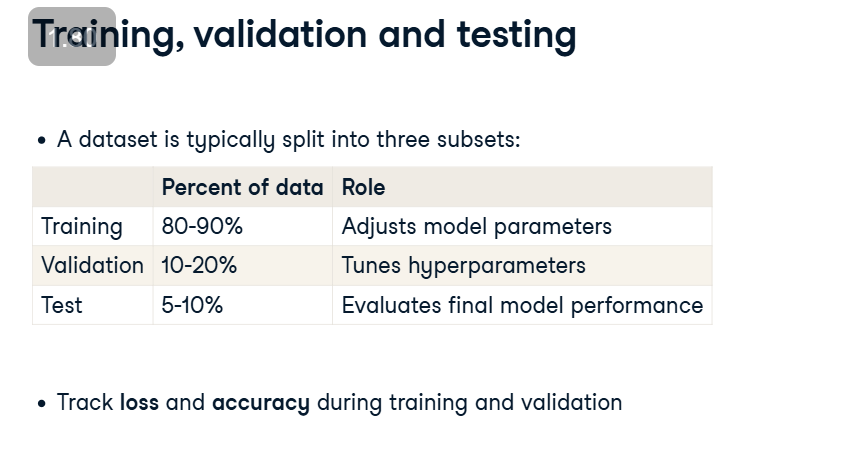

Freeze layers of a model
You are about to fine-tune a model on a new task after loading pre-trained weights. The model contains three linear layers. However, because your dataset is small, you only want to train the last linear layer of this model and freeze the first two linear layers.

The model has already been created and exists under the variable model. You will be using the named_parameters method of the model to list the parameters of the model. Each parameter is described by a name. This name is a string with the following naming convention: x.name where x is the index of the layer.

Remember that a linear layer has two parameters: the weight and the bias.

Instructions
100 XP
Use an if statement to check if a parameter is a weight from the first or second layer.
Freeze the weights of the first two layers of this model

In [96]:
for name, param in model.named_parameters():
  
    # Check for first layer's weight
    if name == '0.weight':
   
        # Freeze this weight
        param.requires_grad = False
        
    # Check for second layer's weight
    if name == '1.weight':
      
        # Freeze this weight
        param.requires_grad = False

Layer initialization
The initialization of the weights of a neural network has been the focus of researchers for many years. When training a network, the method used to initialize the weights has a direct impact on the final performance of the network.

As a machine learning practitioner, you should be able to experiment with different initialization strategies. In this exercise, you are creating a small neural network made of two layers and you are deciding to initialize each layer's weights with the uniform method.

Instructions
100 XP
For each layer (layer0 and layer1), use the uniform initialization method to initialize the weights.

In [95]:
layer0 = nn.Linear(16, 32)
layer1 = nn.Linear(32, 64)

# Use uniform initialization for layer0 and layer1 weights
nn.init.uniform_(layer0.weight)
nn.init.uniform_(layer1.weight)

model = nn.Sequential(layer0, layer1)

## Training loss, validation loss, and Overfitting

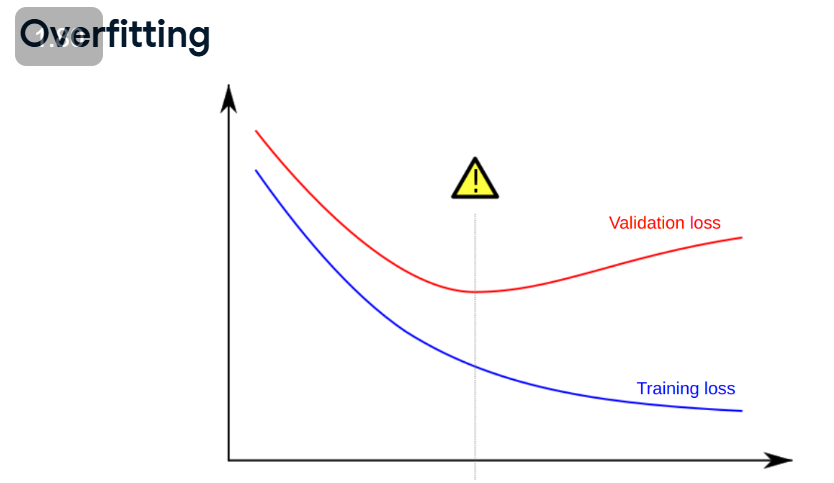

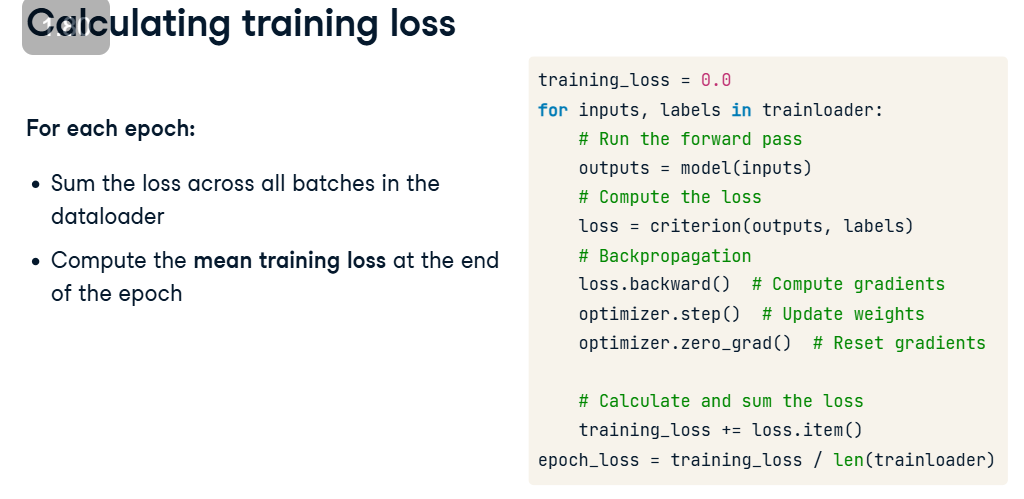

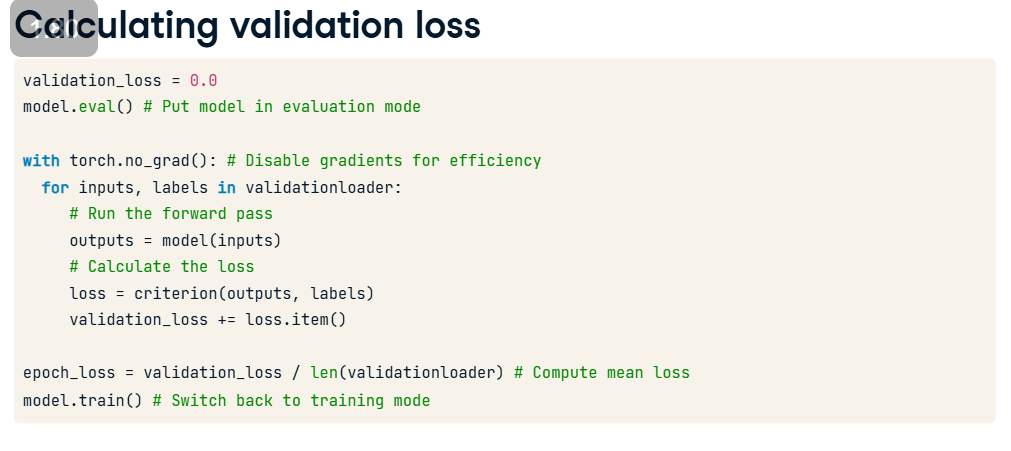

Training loss = the model’s average error on the data it was fit on.
Validation loss = the same error metric computed on a held-out set not used for fitting, used to estimate generalization.

Formally, with loss function (\ell(\hat y,y)) and model (f_\theta):
[
L_{\text{train}}(\theta)=\frac{1}{n}\sum_{i=1}^{n}\ell\big(f_\theta(x_i),y_i\big),\qquad
L_{\text{val}}(\theta)=\frac{1}{m}\sum_{j=1}^{m}\ell\big(f_\theta(\tilde x_j),\tilde y_j\big).
]
Common (\ell): MSE for regression, cross-entropy for classification.

Why both:

* If both high → underfitting/high bias.
* Train ↓, val ≈ same high → still underfitting.
* Train low, val a bit higher but close → good fit.
* Train very low, val rising with epochs → overfitting/high variance.

Typical training curve vs epochs:

* (L_{\text{train}}): monotonically decreases.
* (L_{\text{val}}): decreases at first, then bottoms out and may rise if overfitting starts. Pick the epoch at the minimum (L_{\text{val}}) (early stopping).

Actions when (L_{\text{val}}) is poor or diverges:

* Reduce model capacity or add regularization (L2, dropout).
* Increase data or augmentation.
* Tune optimization (learning rate, batch size).
* Fix data leakage or distribution mismatch.

Related:

* Test loss: computed once on a final, untouched test set for unbiased reporting.
* Cross-validation: average validation loss across (K) folds to reduce variance in the estimate.

Mini example (binary classification, cross-entropy):

* Epoch 5: (L_{\text{train}}=0.35), (L_{\text{val}}=0.38) → reasonable.
* Epoch 20: (L_{\text{train}}=0.05), (L_{\text{val}}=0.62) → overfitting; keep the epoch 5–8 model.

Key difference: training loss measures fit to seen data; validation loss estimates how well the model will generalize to new data and drives model selection.


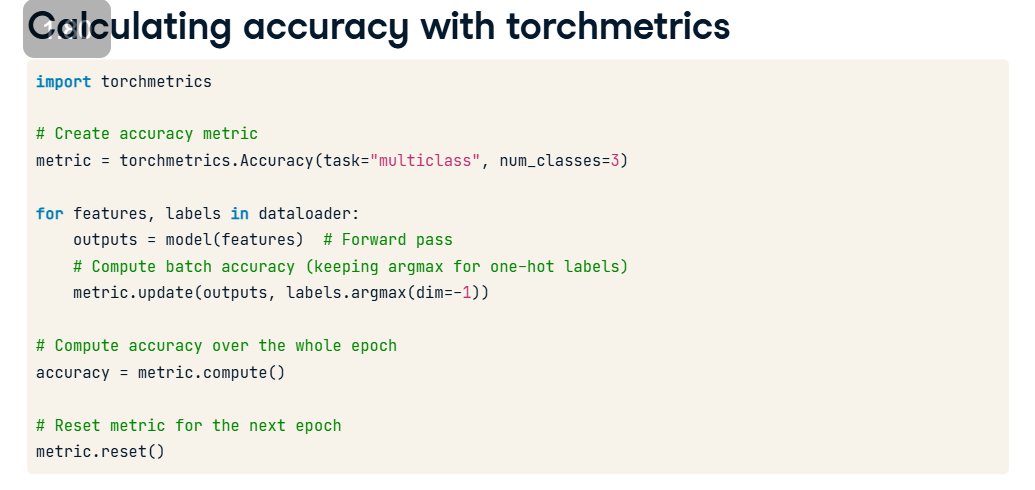

## Writing the evaluation loop
In this exercise, you will write an evaluation loop to compute validation loss. The evaluation loop follows a similar structure to the training loop but without gradient calculations or weight updates.

model, validationloader, and loss function criterion have already been defined to handle predictions, data loading, and loss calculation.

Instructions 1/2
50 XP
1
2
Set the model to evaluation mode.
Sum the current batch loss to the validation_loss variable.

Calculate the mean loss value for the epoch.
Set the model back to training mode

In [97]:
# Set the model to evaluation mode
model.eval()
validation_loss = 0.0

with torch.no_grad():
  for features, labels in validationloader:
      outputs = model(features)
      loss = criterion(outputs, labels)
      # Sum the current loss to the validation_loss variable
      validation_loss += loss.item()
      
# Calculate the mean loss value
validation_loss_epoch = validation_loss / len(validationloader)
print(validation_loss_epoch)

# Set the model back to training mode
model.train()

NameError: name 'validationloader' is not defined

## Calculating accuracy using torchmetrics
Tracking accuracy during training helps identify the best-performing epoch.

In this exercise, you'll use torchmetrics to calculate accuracy on a facemask dataset with three classes. The plot_errors function will highlight misclassified samples, helping you analyze model errors.

torchmetrics package is already imported. Model outputs are softmax probabilities, and labels are one-hot encoded vectors.

Instructions 1/2
50 XP
1
2
Create a "multiclass" accuracy metric with three classes.
Calculate the accuracy for each batch of the dataloader.

In [ ]:
# Create accuracy metric
metric = torchmetrics.Accuracy(num_classes=3, average='macro')
for features, labels in dataloader:
    outputs = model(features)
  
    # Calculate accuracy over the batch
    metric(outputs, labels)